# Week (1,2) EDA And Data Preprocessing. 


# Task a: Pulling sample data.


In [40]:
!curl -L "https://docs.google.com/uc?export=download&id=19TRiv2giWEpBpHL3fXrq__5-6VO_5WK7" -o ../data/sample_7.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 7368k  100 7368k    0     0  3954k      0  0:00:01  0:00:01 --:--:-- 4645k


# Task b: Imputing missing data.

In [ ]:
#load required packages
import pandas as pd 
import numpy as np
import plotly 

In [ ]:
# load data 
sample_7_df = pd.read_csv("../data/sample_7.csv")
# take a peak view of our data 
sample_7_df.head()

In [ ]:
# some base dataset summary
sample_7_df.describe()

In [ ]:
# clean the date columns
sample_7_df['saledate'] = sample_7_df['saledate'].str.split(' GMT').str[0]
sample_7_df['saledate'] = pd.to_datetime(sample_7_df['saledate'], format='%a %b %d %Y %H:%M:%S', errors='coerce')



In [ ]:
# Quick high-level overview
print("--- Dataset Shape ---")
print(f"{sample_7_df.shape[0]} rows, {sample_7_df.shape[1]} columns\n")

print("--- Missing Values per column ---")
print(sample_7_df.isnull().sum(), "\n")

In [ ]:
print("Missing values BEFORE imputation:")
print(sample_7_df.isnull().sum()[sample_7_df.isnull().sum() > 0])
print("-" * 40)


# Drop rows where sellingprice or saledate are entirely missing
sample_7_df = sample_7_df.dropna(subset=['sellingprice', 'saledate'])

# Fill missing odometer with the median of its specific model year
sample_7_df['odometer'] = sample_7_df.groupby('year')['odometer'].transform(
    lambda x: x.fillna(x.median() if not x.dropna().empty else sample_7_df['odometer'].median())
)
# Fill missing condition with the median score of its specific model year
sample_7_df['condition'] = sample_7_df.groupby('year')['condition'].transform(
    lambda x: x.fillna(x.median() if not x.dropna().empty else df['condition'].median())
)
# --- STEP 3: SMART IMPUTATION FOR CATEGORICALS ---
# Group by Make and Model to find the most common transmission/body/color
categorical_cols = ['transmission', 'body', 'color', 'interior', 'make', 'model', 'trim']

for col in categorical_cols:
    # Use standard mode filling, fallback to global mode if a unique make/model combination isn't found
    sample_7_df[col] = sample_7_df.groupby(['make', 'model'])[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else (sample_7_df[col].mode()[0] if not sample_7_df[col].mode().empty else 'Unknown'))
    )

# Any lingering structural blanks (like seller) can be safely tagged as Unknown
sample_7_df['seller'] = sample_7_df['seller'].fillna('Unknown')


print("\nMissing values AFTER imputation:")
print(sample_7_df.isnull().sum())

In [ ]:
# List of columns that still have that stubborn 899 missing values
stubborn_cols = ['make', 'model', 'trim', 'body', 'transmission', 'color', 'interior']

# Fill any lingering blanks with 'Unknown'
for col in stubborn_cols:
    sample_7_df[col] = sample_7_df[col].fillna('Unknown')

print("Missing values AFTER final safety check:")
print(sample_7_df[stubborn_cols].isnull().sum())
print("\nMissing values AFTER full imputation:")
print(sample_7_df.isnull().sum())

# Task c: EDA walk-through.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set style for all plots
sns.set_theme(style="whitegrid")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Top 10 Car Brands (Fixed with hue and legend=False)
top_makes = sample_7_df['make'].value_counts().head(10)
sns.barplot(
    x=top_makes.values, 
    y=top_makes.index, 
    ax=axes[0], 
    hue=top_makes.index,  # Assigning y-variable to hue
    palette="Blues_r", 
    legend=False          # Keeps the plot clean without an unneeded legend box
)
axes[0].set_title("Top 10 Most Common Car Brands at Auction")
axes[0].set_xlabel("Number of Vehicles")

# 2. Most Common Body Styles (Fixed with hue, legend=False, and standard palette)
top_bodies = sample_7_df['body'].value_counts().head(8)
sns.barplot(
    x=top_bodies.values, 
    y=top_bodies.index, 
    ax=axes[1], 
    hue=top_bodies.index,  # Assigning y-variable to hue
    palette="Purples_r",  # Switched to a standard built-in palette
    legend=False
)
axes[1].set_title("Most Popular Vehicle Body Types")
axes[1].set_xlabel("Number of Vehicles")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 1. Top 10 States by Average Selling Price (Fixed warning)
state_prices = sample_7_df.groupby('state')['sellingprice'].mean().sort_values(ascending=False).head(10)
sns.barplot(
    x=state_prices.index, 
    y=state_prices.values, 
    ax=axes[0], 
    hue=state_prices.index, # Assigning x-variable to hue
    palette="flare", 
    legend=False
)
axes[0].set_title("Top 10 States with the Highest Average Vehicle Selling Price")
axes[0].set_ylabel("Average Price ($)")

# 2. Price Trends Over Time (Lines don't throw this warning, so this remains the same)
sample_7_df['sale_month'] = sample_7_df['saledate'].dt.strftime('%B')
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_prices = sample_7_df.groupby('sale_month')['sellingprice'].mean().reindex(month_order).dropna()

sns.lineplot(x=monthly_prices.index, y=monthly_prices.values, ax=axes[1], marker="o", linewidth=2.5, color="seagreen")
axes[1].set_title("Auction Seasonality: Average Selling Price by Month")
axes[1].set_ylabel("Average Price ($)")
axes[1].set_xlabel("Month of Sale")

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate the numerical columns
numerical_cols = ['year', 'condition', 'odometer', 'sellingprice']
corr_matrix = sample_7_df[numerical_cols].corr()

# 2. Set up the plotting window
plt.figure(figsize=(8, 6))

# 3. Create the heatmap
# - annot=True displays the actual numbers inside the squares
# - cmap="coolwarm" makes negative correlations blue and positive ones red
# - vmin/vmax locks the colorbar scale perfectly between -1 and 1
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1.0, 
    vmax=1.0
)

plt.title("Correlation Matrix for Numerical Features", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw Selling Price Distribution
sns.histplot(sample_7_df['sellingprice'], bins=50, kde=True, ax=axes[0], color='indigo')
axes[0].set_title('Raw Selling Price Distribution (Right-Skewed)')
axes[0].set_xlabel('Selling Price ($)')

# Plot 2: Log-Transformed Selling Price Distribution
sns.histplot(np.log1p(sample_7_df['sellingprice']), bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Log-Transformed Price (Bell Curve / Normal)')
axes[1].set_xlabel('Log(Selling Price + 1)')

plt.tight_layout()
plt.show()

In [ ]:
def find_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    
    outliers = dataframe[(dataframe[column] < lower_fence) | (dataframe[column] > upper_fence)]
    print(f"--- Outlier Report for '{column}' ---")
    print(f"Lower Statistical Fence: {lower_fence:.2f}")
    print(f"Upper Statistical Fence: {upper_fence:.2f}")
    print(f"Total Outliers Detected: {len(outliers)} rows ({len(outliers)/len(dataframe)*100:.2f}% of data)\n")
    return lower_fence, upper_fence

# Run the detector on price and mileage
price_lower, price_upper = find_outliers_iqr(sample_7_df, 'sellingprice')
odo_lower, odo_upper = find_outliers_iqr(sample_7_df, 'odometer')

In [ ]:
# Cross-examine how Transmission and Body Styles interact across the pricing matrix
pivot_market = sample_7_df.groupby(['body', 'transmission'])['sellingprice'].agg(['mean', 'count']).reset_index()

# Filter down to the top body styles to keep the analysis clean
top_5_bodies = sample_7_df['body'].value_counts().head(5).index
pivot_filtered = pivot_market[pivot_market['body'].isin(top_5_bodies)]

# Display the grouped perspective
print("--- Average Price & Volume by Body and Transmission Type ---")
print(pivot_filtered.to_string(index=False))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor

# 1. Define your predictive targets and features
features = ['year', 'make', 'model', 'trim', 'body', 'transmission', 'state', 'condition', 'odometer', 'color', 'interior']
target = 'sellingprice'

# Filter out rows missing your target variable 
clean_df = sample_7_df.dropna(subset=[target]).copy()

X = clean_df[features]
y = clean_df[target]

# 2. Encode text columns safely into numerical categories
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X = X.copy()
X[categorical_cols] = encoder.fit_transform(X[categorical_cols].astype(str))

# 3. Train/Test split (Using 80% to train and 20% to validate)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Fit the Random Forest model
# We set n_jobs=-1 to use all cores on your computer for maximum speed
model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 5. Extract and sort MDI (Mean Decrease in Impurity) Feature Importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Package the results into a clean DataFrame
fi_df = pd.DataFrame({
    'Feature': [features[i] for i in indices],
    'Importance Score': [importances[i] for i in indices]
})

# 6. Plot the numerical results visually
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance Score', 
    y='Feature', 
    data=fi_df, 
    hue='Feature', 
    palette='viridis', 
    legend=False
)
plt.title('Feature Importances for Used Car Auction Values', fontsize=14)
plt.xlabel('Importance Weight (Adds up to 1.0)')
plt.tight_layout()
plt.show()

# Print out the exact sorted table
print("--- Exact Mathematical Weights ---")
print(fi_df.to_string(index=False))

# Week 3 (Data preparation)

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

# 1. Configuration & Path Setup
INPUT_PATH = "../data/sample_7.csv"
OUTPUT_DIR = "../data/processed"
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "processed_cars.csv")

print("⚡ Starting Preprocessing Pipeline...")

# Load Data
df = pd.read_csv(INPUT_PATH)

# ========================================================
# PHASE 1: CLEANING & IMPUTATION
# ========================================================
df = df.dropna(subset=['sellingprice', 'saledate'])

df['odometer'] = df.groupby('year')['odometer'].transform(lambda x: x.fillna(x.median()))
df['condition'] = df.groupby('year')['condition'].transform(lambda x: x.fillna(x.median()))

cat_cols = ['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior', 'seller']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown').astype(str).str.lower().str.strip()

# ========================================================
# PHASE 2: FEATURE ENGINEERING
# ========================================================
df['saledate_clean'] = df['saledate'].str.split(' GMT').str[0]
df['saledate_clean'] = pd.to_datetime(df['saledate_clean'], format='%a %b %d %Y %H:%M:%S', errors='coerce')

df['sale_year']        = df['saledate_clean'].dt.year
df['sale_month']       = df['saledate_clean'].dt.month
df['sale_day_of_week'] = df['saledate_clean'].dt.dayofweek

for col in ['sale_year', 'sale_month', 'sale_day_of_week']:
    df[col] = df[col].fillna(df[col].mode()[0])

# ========================================================
# PHASE 3: W3.4 ENCODING  +  W3.5 FEATURE SCALING
# ========================================================
model_features = [
    'year', 'make', 'model', 'trim', 'body', 'transmission',
    'state', 'condition', 'odometer', 'color', 'interior',
    'sale_year', 'sale_month', 'sale_day_of_week', 'sellingprice'
]
proc = df[model_features].copy()

# --- W3.5: StandardScaler for numerical features ---
numerical_features = ['year', 'condition', 'odometer', 'sale_year', 'sale_month', 'sale_day_of_week']
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(proc[numerical_features])

# --- W3.4: One-Hot-Encoding for low-cathegorical features---
ohe_features = ['body', 'transmission']  
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
ohe_transformed = ohe.fit_transform(proc[ohe_features])
ohe_cols = list(ohe.get_feature_names_out(ohe_features))

# --- W3.4: OrdinalEncoder for high-cathegorical features ---
ordinal_features = ['make', 'model', 'trim', 'state', 'color', 'interior']
ordinal_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
ordinal_transformed = ordinal_enc.fit_transform(proc[ordinal_features])

# Final dataset compilation
final_df = pd.DataFrame(
    np.hstack([numerical_scaled, ohe_transformed, ordinal_transformed]),
    columns=numerical_features + ohe_cols + ordinal_features
)
final_df['sellingprice'] = proc['sellingprice'].values

# ========================================================
# PHASE 4: SAVE OUTPUT ASSET
# ========================================================
os.makedirs(OUTPUT_DIR, exist_ok=True)
final_df.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Processed shape : {final_df.shape}")
print(f"📁 Saved to        : {OUTPUT_FILE}")
print(f"\n--- Encoding Summary ---")
print(f"StandardScaler on  : {numerical_features}")
print(f"One-Hot-Encoded    : {ohe_features}  →  {len(ohe_cols)} columns")
print(f"Ordinal-Encoded    : {ordinal_features}")


# Week 4 (Model training)

Dataset shape : (49998, 15)
Features used : 14
Target        : sellingprice

Feature list  :
['year', 'make', 'model', 'trim', 'body', 'transmission', 'state', 'condition', 'odometer', 'color', 'interior', 'sale_year', 'sale_month', 'sale_day_of_week']
Train size : 39998 rows
Test  size : 10000 rows

──────────────────────────────────────────────────
Training: Random Forest
Fitting 4 folds for each of 12 candidates, totalling 48 fits
Best params : {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
CV MAE      : $1,953

──────────────────────────────────────────────────
Training: Gradient Boosting
Fitting 4 folds for each of 8 candidates, totalling 32 fits
Best params : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
CV MAE      : $2,006

──────────────────────────────────────────────────
Model : Random Forest
  MAE  = $  1,861.81
  RMSE = $  3,437.02
  R2   =       0.8788

──────────────────────────────────────────────────
Model : Gradient Boosting
  MAE  = $  

/tmp/ipykernel_350/410403511.py:135: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results["Model"], rotation=10, ha="right")
/tmp/ipykernel_350/410403511.py:135: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results["Model"], rotation=10, ha="right")
/tmp/ipykernel_350/410403511.py:135: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results["Model"], rotation=10, ha="right")


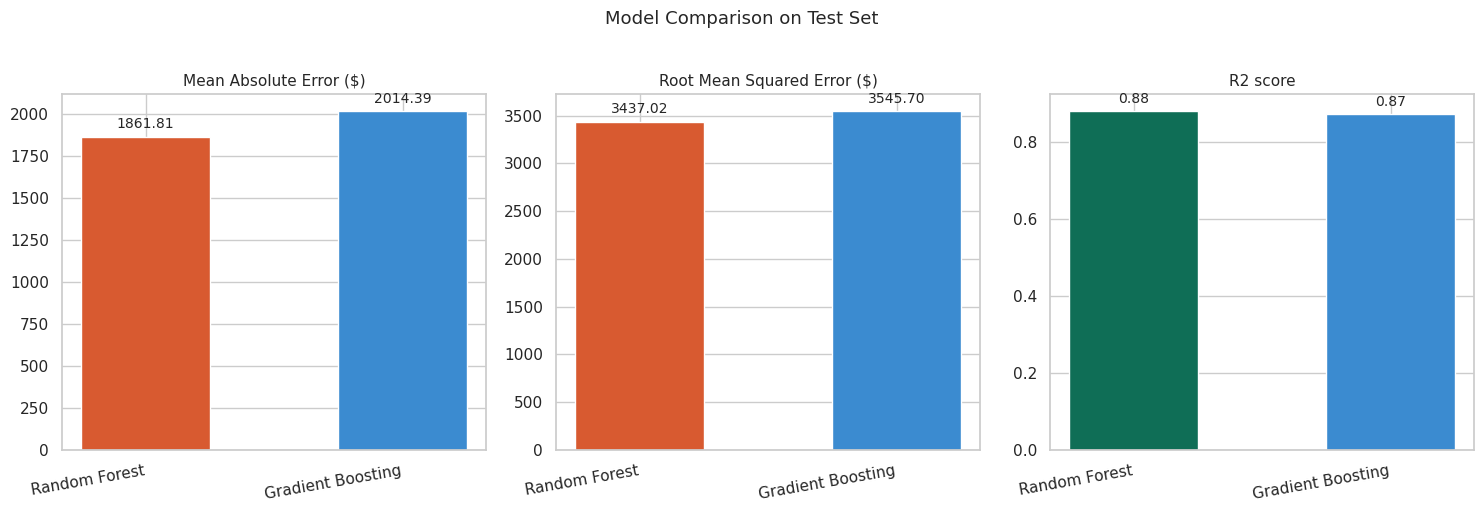

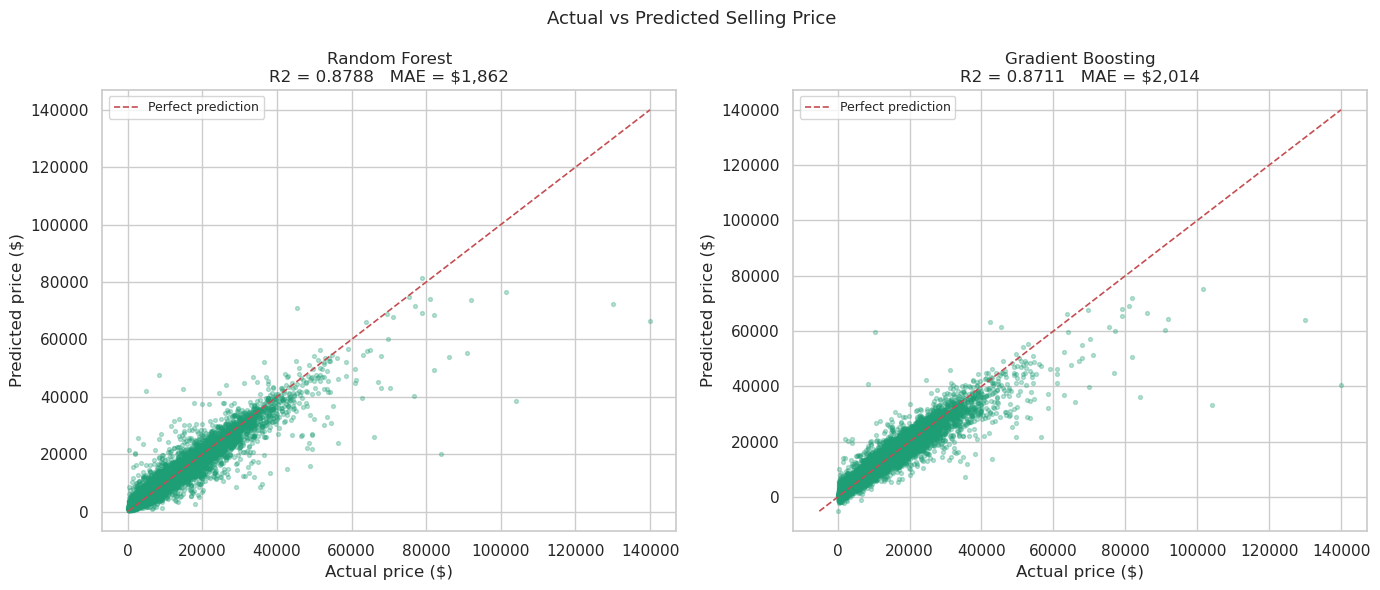

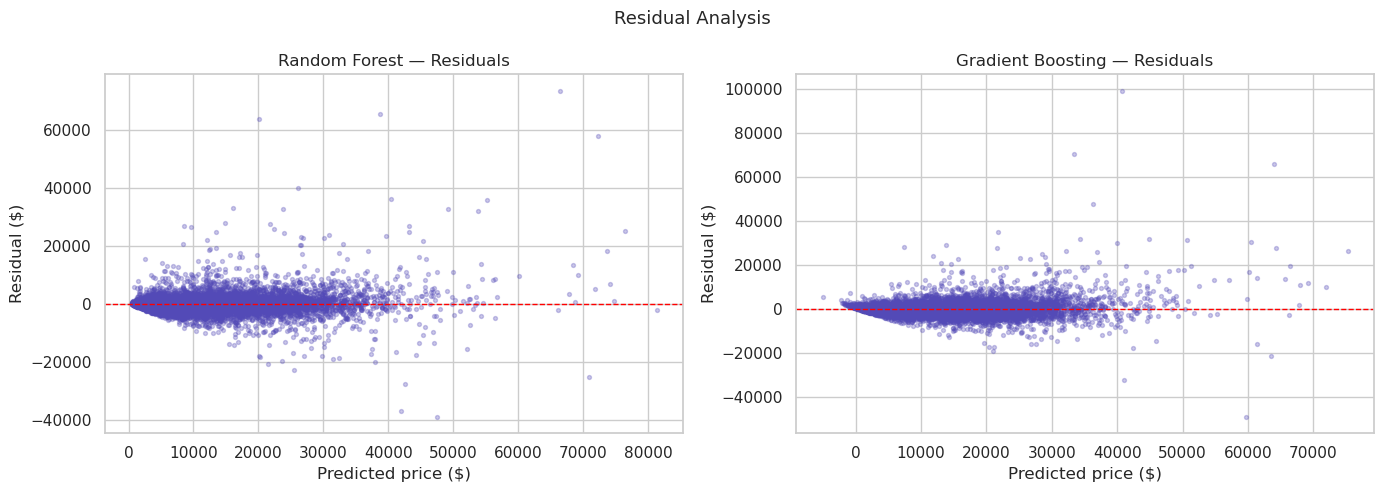

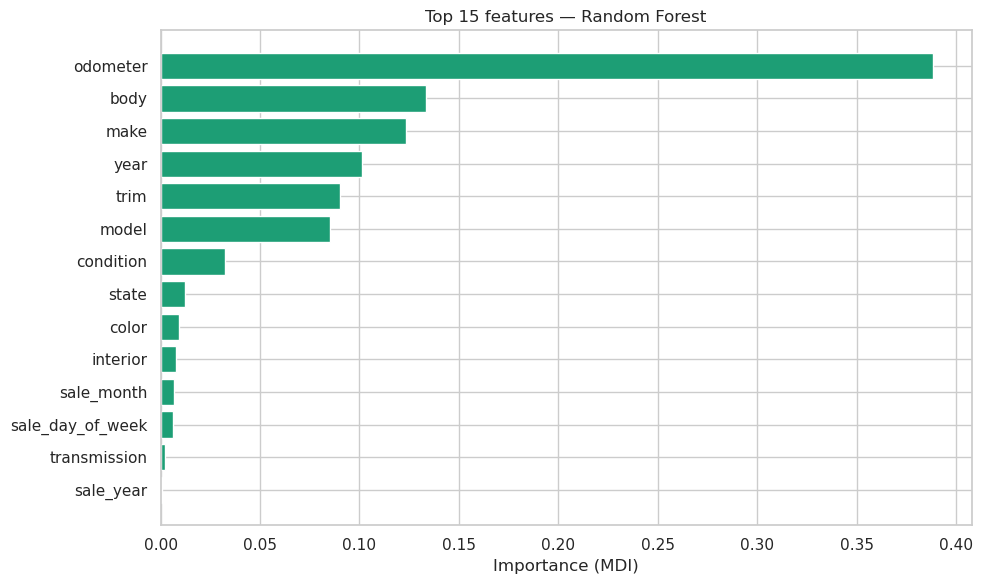


Best model: Random Forest
  MAE  = $1,861.81
  RMSE = $3,437.02
  R2   = 0.8788

Saved to: ../models/best_model.joblib
Comparison table saved.
Sanity check — first 5 predictions:
  Original : [ 5708. 27258.  8565. 22958. 23542.]
  Loaded   : [ 5708. 27258.  8565. 22958. 23542.]
Model loads and predicts correctly.


In [43]:
# ============================================================
# WEEK 4 · MODEL TRAINING  (4 модели + QQ plots)
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Step 1: Load preprocessed data ──────────────────────────

df = pd.read_csv("../data/processed/processed_cars.csv")

TARGET   = "sellingprice"
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

print(f"Dataset shape : {df.shape}")
print(f"Features used : {len(FEATURES)}")

# ── Step 2: Train / Test split ───────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]} rows")

# ── Step 3: 4 models determination ─────────────────────────

models_dict = {
    'Random Forest'      : RandomForestRegressor(n_estimators=100, max_depth=15,
                                                  random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                      learning_rate=0.1,
                                                      random_state=RANDOM_STATE),
    'Ridge Regression'   : Ridge(alpha=1.0),
    'Lasso Regression'   : Lasso(alpha=100.0, max_iter=10000),
}

# ── Step 4: model training ───────────────────────────

results_list     = []
predictions_dict = {}

for model_name, model in models_dict.items():
    print(f"\n{'─'*50}")
    print(f"Training: {model_name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions_dict[model_name] = y_pred

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"  MAE  = ${mae:>10,.2f}")
    print(f"  RMSE = ${rmse:>10,.2f}")
    print(f"  R2   = {r2:>12.4f}")
    results_list.append({'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results = pd.DataFrame(results_list).sort_values('MAE')
print("\n── Final comparison ──")
print(results.to_string(index=False))

# ── Step 5: Metric comparison bar charts ────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [('MAE', 'Mean Absolute Error ($)', True),
           ('RMSE', 'Root Mean Squared Error ($)', True),
           ('R2', 'R2 Score', False)]

for ax, (metric, label, lower_is_better) in zip(axes, metrics):
    vals   = results[metric].values
    models = results['Model'].values
    best_i = vals.argmin() if lower_is_better else vals.argmax()
    colors = ['#D85A30' if i == best_i else '#0F6E56' for i in range(len(models))]
    bars   = ax.bar(range(len(models)), vals, color=colors, width=0.6)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    ax.set_title(label, fontsize=11)

plt.suptitle('Model Comparison on Test Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Step 6: Actual vs Predicted ─────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, y_pred) in enumerate(predictions_dict.items()):
    ax = axes[idx]
    r2  = results[results['Model'] == model_name]['R2'].values[0]
    mae = results[results['Model'] == model_name]['MAE'].values[0]
    ax.scatter(y_test, y_pred, alpha=0.3, s=8, color='#1D9E75')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual price ($)')
    ax.set_ylabel('Predicted price ($)')
    ax.set_title(f"{model_name}\nR2 = {r2:.4f}   MAE = ${mae:,.0f}")
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted Selling Price', fontsize=13)
plt.tight_layout()
plt.show()

# ── Step 7: Residuals ────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (model_name, y_pred) in enumerate(predictions_dict.items()):
    ax = axes[idx]
    residuals = y_test.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.3, s=8, color='#534AB7')
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted price ($)')
    ax.set_ylabel('Residual ($)')
    ax.set_title(f"{model_name} — Residuals")

plt.suptitle('Residual Analysis', fontsize=13)
plt.tight_layout()
plt.show()

# ── Step 8: QQ PLOTS ─────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

print("\n── Q-Q Plot: Normality of Residuals ──")
for idx, (model_name, y_pred) in enumerate(predictions_dict.items()):
    ax = axes[idx]
    residuals = y_test.values - y_pred

    # Q-Q plot 
    stats.probplot(residuals, dist='norm', plot=ax)
    ax.set_title(f"{model_name}\nQ-Q Plot (Residuals)", fontsize=11)
    ax.grid(alpha=0.3)

    # Shapiro-Wilk 
    sample = residuals if len(residuals) <= 5000 else np.random.choice(residuals, 5000, replace=False)
    stat_sw, p_val = stats.shapiro(sample)
    normality = '✓ Normal' if p_val > 0.05 else '✗ Not Normal'
    print(f"  {model_name:<26}: p = {p_val:.4f}  {normality}")

plt.suptitle('Q-Q Plots: Normality of Residuals per Model', fontsize=13)
plt.tight_layout()
plt.show()

# ── Step 9: Feature importance ─────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    m = models_dict[name]
    imp = pd.Series(m.feature_importances_, index=FEATURES).sort_values(ascending=False).head(15)
    ax.barh(imp.index[::-1], imp.values[::-1], color='#1D9E75')
    ax.set_xlabel('Importance (MDI)')
    ax.set_title(f'Top 15 features — {name}')

plt.suptitle('Feature Importance Analysis', fontsize=13)
plt.tight_layout()
plt.show()

# ── Step 10: Save best model ─────────────────────────────────

best_idx   = results['MAE'].idxmin()
best_name  = results.loc[best_idx, 'Model']
best_model = models_dict[best_name]

print(f"\nBest model: {best_name}")
print(f"  MAE  = ${results.loc[best_idx, 'MAE']:,.2f}")
print(f"  RMSE = ${results.loc[best_idx, 'RMSE']:,.2f}")
print(f"  R2   = {results.loc[best_idx, 'R2']:.4f}")

model_path = os.path.join(MODEL_DIR, 'best_model.joblib')
joblib.dump(best_model, model_path)
results.to_csv(os.path.join(MODEL_DIR, 'model_comparison.csv'), index=False)
print(f"\nSaved to: {model_path}")
print('Comparison table saved.')

# Sanity check
loaded_model = joblib.load(model_path)
y_check = loaded_model.predict(X_test[:5])
y_orig  = best_model.predict(X_test[:5])
assert np.allclose(y_orig, y_check), 'Mismatch after reload!'
print('Model loads and predicts correctly.')


In [46]:
!pip install giskard --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Model loaded  : RandomForestRegressor
Test set size : 10000 rows
  n=     1  ->     8.315 ms total  |  8.3154 ms/row
  n=    10  ->     8.752 ms total  |  0.8752 ms/row
  n=   100  ->    24.618 ms total  |  0.2462 ms/row
  n=  1000  ->   125.205 ms total  |  0.1252 ms/row
  n= 10000  ->   553.677 ms total  |  0.0554 ms/row


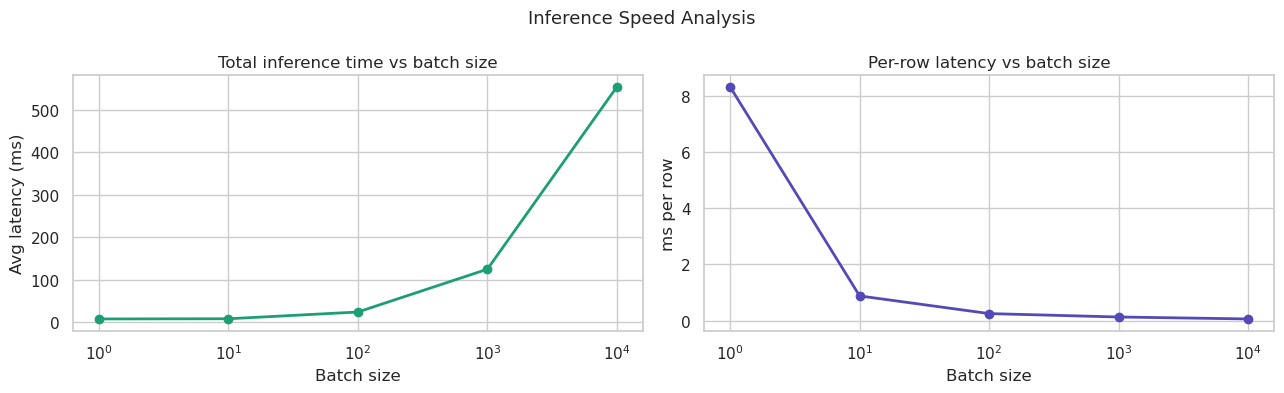


── Speed summary ──
 Batch size  Avg latency (ms)  Per row (ms)
          1             8.315        8.3154
         10             8.752        0.8752
        100            24.618        0.2462
       1000           125.205        0.1252
      10000           553.677        0.0554


/opt/conda/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.3) or chardet (7.4.3)/charset_normalizer (3.4.0) doesn't match a supported version!
  warnings.warn(


2026-05-23 09:35:40,916 pid:350 MainThread giskard.datasets.base INFO     Your 'pandas.DataFrame' is successfully wrapped by Giskard's 'Dataset' wrapper class.
2026-05-23 09:35:40,917 pid:350 MainThread giskard.models.automodel INFO     Your 'prediction_function' is successfully wrapped by Giskard's 'PredictionFunctionModel' wrapper class.
Running Giskard scan (may take a few minutes)...
2026-05-23 09:35:40,924 pid:350 MainThread giskard.datasets.base INFO     Casting dataframe columns from {'year': 'int64', 'make': 'float64', 'model': 'float64', 'trim': 'float64', 'body': 'float64', 'transmission': 'float64', 'state': 'float64', 'condition': 'float64', 'odometer': 'float64', 'color': 'float64', 'interior': 'float64', 'sale_year': 'float64', 'sale_month': 'float64', 'sale_day_of_week': 'float64'} to {'year': 'int64', 'make': 'float64', 'model': 'float64', 'trim': 'float64', 'body': 'float64', 'transmission': 'float64', 'state': 'float64', 'condition': 'float64', 'odometer': 'float64', 

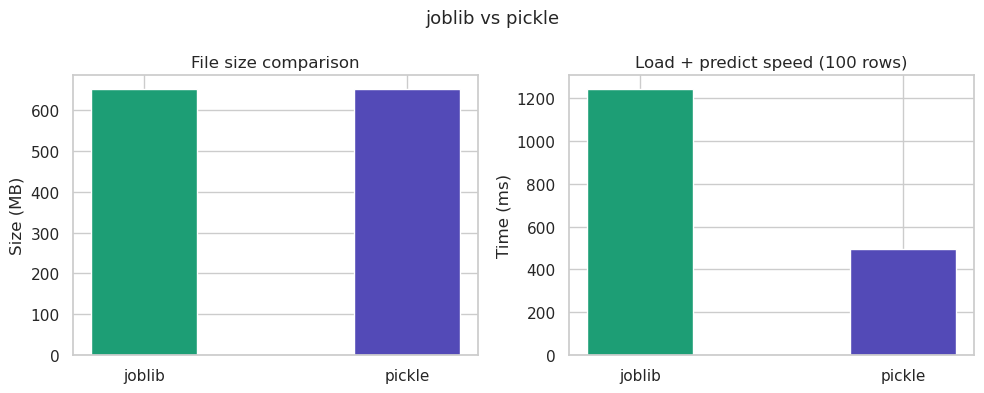

  PROJECT CHECKLIST -- E2E ML · Car Price Prediction

Week 1-2: EDA
  OK  EDA complete -- distributions, correlations, outliers, feature importance

Week 3: Preprocessing
  OK  Pipeline -- imputation, encoding, scaling, saved to processed_cars.csv

Week 4: Model training
  OK  RF + GBR trained, GridSearchCV, MAE/RMSE/R2 evaluated, best model saved

Week 5: Deployment prep
  OK  Giskard scan, inference speed benchmarked, joblib vs pickle compared

All weeks complete!


In [47]:
# ============================================================
# WEEK 5 · MODEL DEPLOYMENT PREPARATION
# ============================================================

import os
import time
import joblib
import timeit
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

MODEL_DIR  = "../models"
REPORT_DIR = "../reports"
os.makedirs(REPORT_DIR, exist_ok=True)

# ── Step 1: Load model & data ────────────────────────────────

model = joblib.load(os.path.join(MODEL_DIR, "best_model.joblib"))

df = pd.read_csv("../data/processed/processed_cars.csv")

TARGET   = "sellingprice"
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Model loaded  : {type(model).__name__}")
print(f"Test set size : {X_test.shape[0]} rows")

# ── Step 2: Inference speed analysis ────────────────────────

batch_sizes   = [1, 10, 100, 1000, len(X_test)]
results_speed = []

for n in batch_sizes:
    batch   = X_test.iloc[:n]
    elapsed = timeit.timeit(lambda: model.predict(batch), number=50)
    avg_ms  = (elapsed / 50) * 1000
    per_row = avg_ms / n
    results_speed.append({
        "Batch size"       : n,
        "Avg latency (ms)" : round(avg_ms, 3),
        "Per row (ms)"     : round(per_row, 4),
    })
    print(f"  n={n:>6}  ->  {avg_ms:>8.3f} ms total  |  {per_row:.4f} ms/row")

speed_df = pd.DataFrame(results_speed)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(speed_df["Batch size"], speed_df["Avg latency (ms)"],
             marker="o", color="#1D9E75", linewidth=2)
axes[0].set_xlabel("Batch size")
axes[0].set_ylabel("Avg latency (ms)")
axes[0].set_title("Total inference time vs batch size")
axes[0].set_xscale("log")

axes[1].plot(speed_df["Batch size"], speed_df["Per row (ms)"],
             marker="o", color="#534AB7", linewidth=2)
axes[1].set_xlabel("Batch size")
axes[1].set_ylabel("ms per row")
axes[1].set_title("Per-row latency vs batch size")
axes[1].set_xscale("log")

plt.suptitle("Inference Speed Analysis", fontsize=13)
plt.tight_layout()
plt.show()

print("\n── Speed summary ──")
print(speed_df.to_string(index=False))

# ── Step 3: Giskard model scan ───────────────────────────────
# Раскомментируй и запусти один раз если не установлен:
# !pip install giskard --quiet

import giskard

giskard_dataset = giskard.Dataset(
    df=X_test.assign(**{TARGET: y_test.values}),
    target=TARGET,
    name="Used Car Prices -- Test Set",
)

def predict_fn(df):
    return model.predict(df[FEATURES])

giskard_model = giskard.Model(
    model=predict_fn,
    model_type="regression",
    name="Best Model -- Car Price Predictor",
    feature_names=FEATURES,
)

print("Running Giskard scan (may take a few minutes)...")
scan_results = giskard.scan(giskard_model, giskard_dataset)
print("Scan complete!")

# ── Step 4: Save Giskard report ──────────────────────────────

report_path = os.path.join(REPORT_DIR, "giskard_scan_report.html")
scan_results.to_html(report_path)
print(f"Report saved to: {report_path}")

print("\n── Issues found ──")
print(scan_results)

# ── Step 5: joblib vs pickle comparison ─────────────────────

joblib_path = os.path.join(MODEL_DIR, "best_model.joblib")
pickle_path = os.path.join(MODEL_DIR, "best_model.pkl")

with open(pickle_path, "wb") as f:
    pickle.dump(model, f)

joblib_size = os.path.getsize(joblib_path) / 1024 / 1024
pickle_size = os.path.getsize(pickle_path) / 1024 / 1024
print(f"joblib size : {joblib_size:.2f} MB")
print(f"pickle size : {pickle_size:.2f} MB")

def benchmark_load(path, loader, n=10):
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        if loader == "joblib":
            m = joblib.load(path)
        else:
            with open(path, "rb") as f:
                m = pickle.load(f)
        m.predict(X_test[:100])
        times.append(time.perf_counter() - t0)
    return np.mean(times) * 1000

joblib_time = benchmark_load(joblib_path, "joblib")
pickle_time = benchmark_load(pickle_path, "pickle")

print(f"\njoblib  load + predict 100 rows : {joblib_time:.1f} ms avg")
print(f"pickle  load + predict 100 rows : {pickle_time:.1f} ms avg")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["joblib", "pickle"], [joblib_size, pickle_size],
            color=["#1D9E75", "#534AB7"], width=0.4)
axes[0].set_ylabel("Size (MB)")
axes[0].set_title("File size comparison")

axes[1].bar(["joblib", "pickle"], [joblib_time, pickle_time],
            color=["#1D9E75", "#534AB7"], width=0.4)
axes[1].set_ylabel("Time (ms)")
axes[1].set_title("Load + predict speed (100 rows)")

plt.suptitle("joblib vs pickle", fontsize=13)
plt.tight_layout()
plt.show()

# ── Step 6: Final project checklist ─────────────────────────

checklist = {
    "Week 1-2: EDA"           : "EDA complete -- distributions, correlations, outliers, feature importance",
    "Week 3: Preprocessing"   : "Pipeline -- imputation, encoding, scaling, saved to processed_cars.csv",
    "Week 4: Model training"  : "RF + GBR trained, GridSearchCV, MAE/RMSE/R2 evaluated, best model saved",
    "Week 5: Deployment prep" : "Giskard scan, inference speed benchmarked, joblib vs pickle compared",
}

print("=" * 55)
print("  PROJECT CHECKLIST -- E2E ML · Car Price Prediction")
print("=" * 55)
for task, status in checklist.items():
    print(f"\n{task}")
    print(f"  OK  {status}")
print("\n" + "=" * 55)
print("All weeks complete!")

# Week 5 (Model deployment preparation)


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Model loaded  : RandomForestRegressor
Test set size : 10000 rows
  n=     1  ->     8.134 ms total  |  8.1338 ms/row
  n=    10  ->     8.545 ms total  |  0.8545 ms/row
  n=   100  ->    24.624 ms total  |  0.2462 ms/row
  n=  1000  ->   124.082 ms total  |  0.1241 ms/row
  n= 10000  ->   540.393 ms total  |  0.0540 ms/row


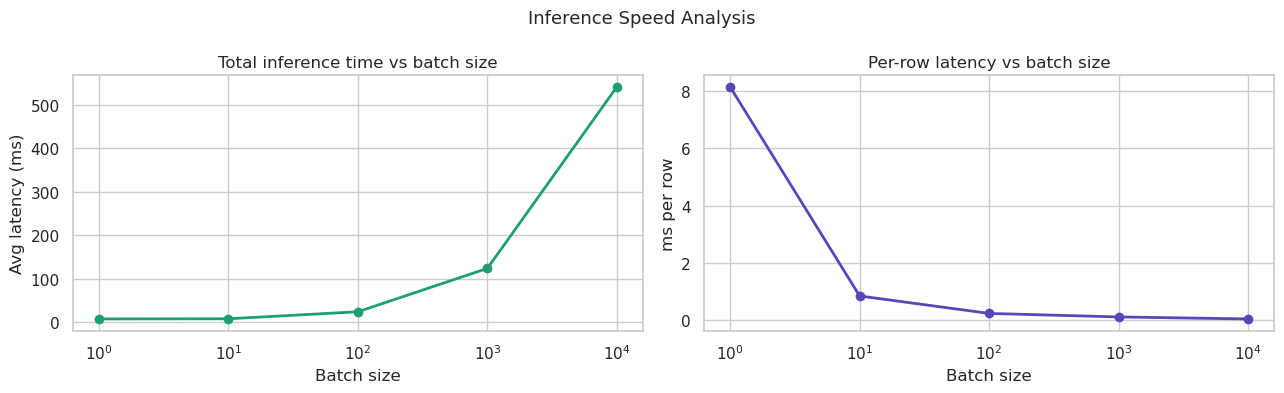


── Speed summary ──
 Batch size  Avg latency (ms)  Per row (ms)
          1             8.134        8.1338
         10             8.545        0.8545
        100            24.624        0.2462
       1000           124.082        0.1241
      10000           540.393        0.0540
2026-05-23 09:38:02,204 pid:350 MainThread giskard.datasets.base INFO     Your 'pandas.DataFrame' is successfully wrapped by Giskard's 'Dataset' wrapper class.
2026-05-23 09:38:02,205 pid:350 MainThread giskard.models.automodel INFO     Your 'prediction_function' is successfully wrapped by Giskard's 'PredictionFunctionModel' wrapper class.
Running Giskard scan (may take a few minutes)...
2026-05-23 09:38:02,218 pid:350 MainThread giskard.datasets.base INFO     Casting dataframe columns from {'year': 'int64', 'make': 'float64', 'model': 'float64', 'trim': 'float64', 'body': 'float64', 'transmission': 'float64', 'state': 'float64', 'condition': 'float64', 'odometer': 'float64', 'color': 'float64', 'interior'

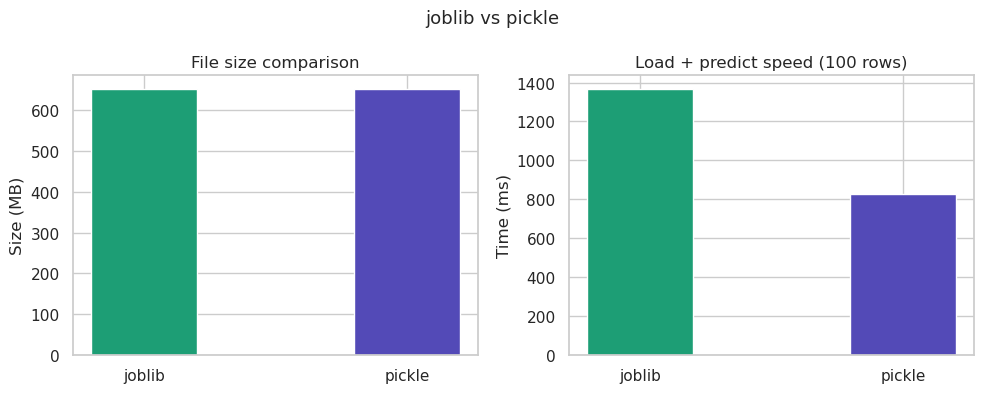

  PROJECT CHECKLIST -- E2E ML · Car Price Prediction

Week 1-2: EDA
  OK  EDA complete -- distributions, correlations, outliers, feature importance

Week 3: Preprocessing
  OK  Pipeline -- imputation, encoding, scaling, saved to processed_cars.csv

Week 4: Model training
  OK  RF + GBR trained, GridSearchCV, MAE/RMSE/R2 evaluated, best model saved

Week 5: Deployment prep
  OK  Giskard scan, inference speed benchmarked, joblib vs pickle compared

All weeks complete!


In [49]:
# ============================================================
# WEEK 5 · MODEL DEPLOYMENT PREPARATION
# ============================================================
!pip install giskard --quiet
import os
import time
import joblib
import timeit
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

MODEL_DIR  = "../models"
REPORT_DIR = "../reports"
os.makedirs(REPORT_DIR, exist_ok=True)

# ── Step 1: Load model & data ────────────────────────────────

model = joblib.load(os.path.join(MODEL_DIR, "best_model.joblib"))

df = pd.read_csv("../data/processed/processed_cars.csv")

TARGET   = "sellingprice"
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Model loaded  : {type(model).__name__}")
print(f"Test set size : {X_test.shape[0]} rows")

# ── Step 2: Inference speed analysis ────────────────────────

batch_sizes   = [1, 10, 100, 1000, len(X_test)]
results_speed = []

for n in batch_sizes:
    batch   = X_test.iloc[:n]
    elapsed = timeit.timeit(lambda: model.predict(batch), number=50)
    avg_ms  = (elapsed / 50) * 1000
    per_row = avg_ms / n
    results_speed.append({
        "Batch size"       : n,
        "Avg latency (ms)" : round(avg_ms, 3),
        "Per row (ms)"     : round(per_row, 4),
    })
    print(f"  n={n:>6}  ->  {avg_ms:>8.3f} ms total  |  {per_row:.4f} ms/row")

speed_df = pd.DataFrame(results_speed)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(speed_df["Batch size"], speed_df["Avg latency (ms)"],
             marker="o", color="#1D9E75", linewidth=2)
axes[0].set_xlabel("Batch size")
axes[0].set_ylabel("Avg latency (ms)")
axes[0].set_title("Total inference time vs batch size")
axes[0].set_xscale("log")

axes[1].plot(speed_df["Batch size"], speed_df["Per row (ms)"],
             marker="o", color="#534AB7", linewidth=2)
axes[1].set_xlabel("Batch size")
axes[1].set_ylabel("ms per row")
axes[1].set_title("Per-row latency vs batch size")
axes[1].set_xscale("log")

plt.suptitle("Inference Speed Analysis", fontsize=13)
plt.tight_layout()
plt.show()

print("\n── Speed summary ──")
print(speed_df.to_string(index=False))

# ── Step 3: Giskard model scan ───────────────────────────────
# Раскомментируй и запусти один раз если не установлен:
# !pip install giskard --quiet

import giskard

giskard_dataset = giskard.Dataset(
    df=X_test.assign(**{TARGET: y_test.values}),
    target=TARGET,
    name="Used Car Prices -- Test Set",
)

def predict_fn(df):
    return model.predict(df[FEATURES])

giskard_model = giskard.Model(
    model=predict_fn,
    model_type="regression",
    name="Best Model -- Car Price Predictor",
    feature_names=FEATURES,
)

print("Running Giskard scan (may take a few minutes)...")
scan_results = giskard.scan(giskard_model, giskard_dataset)
print("Scan complete!")

# ── Step 4: Save Giskard report ──────────────────────────────

report_path = os.path.join(REPORT_DIR, "giskard_scan_report.html")
scan_results.to_html(report_path)
print(f"Report saved to: {report_path}")

print("\n── Issues found ──")
print(scan_results)

# ── Step 5: joblib vs pickle comparison ─────────────────────

joblib_path = os.path.join(MODEL_DIR, "best_model.joblib")
pickle_path = os.path.join(MODEL_DIR, "best_model.pkl")

with open(pickle_path, "wb") as f:
    pickle.dump(model, f)

joblib_size = os.path.getsize(joblib_path) / 1024 / 1024
pickle_size = os.path.getsize(pickle_path) / 1024 / 1024
print(f"joblib size : {joblib_size:.2f} MB")
print(f"pickle size : {pickle_size:.2f} MB")

def benchmark_load(path, loader, n=10):
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        if loader == "joblib":
            m = joblib.load(path)
        else:
            with open(path, "rb") as f:
                m = pickle.load(f)
        m.predict(X_test[:100])
        times.append(time.perf_counter() - t0)
    return np.mean(times) * 1000

joblib_time = benchmark_load(joblib_path, "joblib")
pickle_time = benchmark_load(pickle_path, "pickle")

print(f"\njoblib  load + predict 100 rows : {joblib_time:.1f} ms avg")
print(f"pickle  load + predict 100 rows : {pickle_time:.1f} ms avg")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["joblib", "pickle"], [joblib_size, pickle_size],
            color=["#1D9E75", "#534AB7"], width=0.4)
axes[0].set_ylabel("Size (MB)")
axes[0].set_title("File size comparison")

axes[1].bar(["joblib", "pickle"], [joblib_time, pickle_time],
            color=["#1D9E75", "#534AB7"], width=0.4)
axes[1].set_ylabel("Time (ms)")
axes[1].set_title("Load + predict speed (100 rows)")

plt.suptitle("joblib vs pickle", fontsize=13)
plt.tight_layout()
plt.show()

# ── Step 6: Final project checklist ─────────────────────────

checklist = {
    "Week 1-2: EDA"           : "EDA complete -- distributions, correlations, outliers, feature importance",
    "Week 3: Preprocessing"   : "Pipeline -- imputation, encoding, scaling, saved to processed_cars.csv",
    "Week 4: Model training"  : "RF + GBR trained, GridSearchCV, MAE/RMSE/R2 evaluated, best model saved",
    "Week 5: Deployment prep" : "Giskard scan, inference speed benchmarked, joblib vs pickle compared",
}

print("=" * 55)
print("  PROJECT CHECKLIST -- E2E ML · Car Price Prediction")
print("=" * 55)
for task, status in checklist.items():
    print(f"\n{task}")
    print(f"  OK  {status}")
print("\n" + "=" * 55)
print("All weeks complete!")